In this notebook, we clean the labeled data by removing unlabeled samples, low-speed segments, and high-yaw-rate (turning) segments.

**Input**: `data/interim/labeled/labeled_dataset.csv`  
**Output**: `data/interim/cleaned/cleaned_dataset.csv`  

The cleaned dataset keeps the derived columns `net_speed` and `yaw_rate` for downstream checks and windowing.

In [23]:
from pathlib import Path
import sys
import pandas as pd

# Make project root importable whether CWD is repo root or notebooks/
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / 'src').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.labels import plot_labeled_sensors, plot_labeled_acc, plot_labeled_gyro, plot_labeled_odo

In [24]:
# Loading the labeled run
labeled_run_path = PROJECT_ROOT / "data" / "interim" / "labeled" / "labeled_dataset.csv"

if not labeled_run_path.exists():
    raise FileNotFoundError(f"Labeled dataset not found: {labeled_run_path}\nPlease run 03_labelling.ipynb first.")

labeled_df = pd.read_csv(labeled_run_path, low_memory=False)

if 'label' not in labeled_df.columns:
    raise KeyError("Required column 'label' not found in labeled dataset.")

labeled_df['label'] = labeled_df['label'].astype('string').str.strip()
labeled_df.loc[labeled_df['label'].isin(['', 'nan', 'None', '<NA>']), 'label'] = pd.NA

print(f"Loaded labeled dataset: {labeled_run_path}")
print(f"Shape: {labeled_df.shape}")
print(f"Columns: {list(labeled_df.columns)}")
print(f"Unique run_ids: {labeled_df['run_id'].nunique()}")
print(f"\nRun IDs:")
for run_id in sorted(labeled_df['run_id'].unique()):
    n_samples = len(labeled_df[labeled_df['run_id'] == run_id])
    print(f"  - {run_id}: {n_samples} samples")

Loaded labeled dataset: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/interim/labeled/labeled_dataset.csv
Shape: (871377, 12)
Columns: ['t', 't_rel', 'run_id', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'v1', 'v2', 'label']
Unique run_ids: 3

Run IDs:
  - log_20260223_142511.490: 292115 samples
  - log_20260226_102148.990: 219335 samples
  - log_20260309_141435.414: 359927 samples


In [25]:
# Removing unlabeled samples
n_before_unlabeled_drop = len(labeled_df)
labeled_df = labeled_df.dropna(subset=['label']).copy()
n_removed_unlabeled = n_before_unlabeled_drop - len(labeled_df)

print(f"\nRemoved unlabeled samples: {n_removed_unlabeled}")
print(f"Samples after unlabeled removal: {len(labeled_df)}")
print(f"Shape: {labeled_df.shape}")
print(f"Unique run_ids: {labeled_df['run_id'].nunique()}")
for run_id in sorted(labeled_df['run_id'].unique()):
    n_samples = len(labeled_df[labeled_df['run_id'] == run_id])
    print(f"  - {run_id}: {n_samples} samples")


Removed unlabeled samples: 648077
Samples after unlabeled removal: 223300
Shape: (223300, 12)
Unique run_ids: 3
  - log_20260223_142511.490: 39500 samples
  - log_20260226_102148.990: 18000 samples
  - log_20260309_141435.414: 165800 samples


In [26]:
# Adding derived odometry columns before low-velocity filtering
W = 0.67  # wheel distance in meters (inner to inner distance is 65 cm, outer to outer distance is 69 cm)

if W is None or W <= 0:
    raise ValueError("Please set W to the wheel distance in meters (W > 0) before running this cell.")

labeled_df['net_speed'] = (labeled_df['v1'] + labeled_df['v2']) / 2.0
labeled_df['yaw_rate'] = (labeled_df['v1'] - labeled_df['v2']) / W

print("Added columns: net_speed, yaw_rate")
print(labeled_df[['v1', 'v2', 'net_speed', 'yaw_rate']].head())

Added columns: net_speed, yaw_rate
             v1        v2  net_speed  yaw_rate
31019  0.406051  0.573000   0.489526 -0.249177
31020  0.384789  0.570368   0.477579 -0.276984
31021  0.385667  0.585974   0.485821 -0.298967
31022  0.391059  0.599647   0.495353 -0.311326
31023  0.402507  0.593779   0.498143 -0.285482


In [27]:
# Cleaning thresholds (fixed values) + percentile sanity checks
low_speed_threshold = 0.4
turning_threshold = 0.2

if turning_threshold <= 0:
    raise ValueError("turning_threshold must be > 0")

print("Configured fixed thresholds:")
print(f"  - low_speed_threshold: {low_speed_threshold:.3f} m/s")
print(f"  - turning_threshold: {turning_threshold:.3f} rad/s")

# Percentile check for |yaw_rate| to validate fixed threshold choice
abs_yaw = labeled_df['yaw_rate'].abs()
percentile_levels = [50, 75, 90, 95, 97.5, 99]
global_percentiles = abs_yaw.quantile([p / 100 for p in percentile_levels]).rename('global')

print("\nGlobal |yaw_rate| percentiles (rad/s):")
for p in percentile_levels:
    print(f"  - P{p:>4}: {global_percentiles.loc[p / 100]:.4f}")

per_run_percentiles = (
    labeled_df.groupby('run_id')['yaw_rate']
    .apply(lambda s: s.abs().quantile([0.9, 0.95, 0.99]))
    .unstack()
    .rename(columns={0.9: 'p90', 0.95: 'p95', 0.99: 'p99'})
    .sort_index()
)

print("\nPer-run |yaw_rate| percentiles (rad/s):")
print(per_run_percentiles.to_string())

print(f"\nSamples above turning threshold ({turning_threshold:.3f} rad/s): {int((abs_yaw > turning_threshold).sum())}")

Configured fixed thresholds:
  - low_speed_threshold: 0.400 m/s
  - turning_threshold: 0.200 rad/s

Global |yaw_rate| percentiles (rad/s):
  - P  50: 0.0448
  - P  75: 0.0841
  - P  90: 0.1385
  - P  95: 0.1839
  - P97.5: 0.2399
  - P  99: 0.3548

Per-run |yaw_rate| percentiles (rad/s):
                              p90       p95       p99
run_id                                               
log_20260223_142511.490  0.152717  0.229849  0.844409
log_20260226_102148.990  0.143989  0.209909  0.343680
log_20260309_141435.414  0.135244  0.175373  0.283281

Samples above turning threshold (0.200 rad/s): 9010


In [28]:
# Unlabel low-velocity and strong-turning segments, then drop unlabeled samples
low_velocity_mask = labeled_df['net_speed'] < low_speed_threshold
turning_mask = labeled_df['yaw_rate'].abs() > turning_threshold
combined_unlabel_mask = low_velocity_mask | turning_mask

n_total_before = len(labeled_df)
n_unlabel_low_velocity = int(low_velocity_mask.sum())
n_unlabel_turning = int(turning_mask.sum())
n_unlabel_total = int(combined_unlabel_mask.sum())
n_overlap = int((low_velocity_mask & turning_mask).sum())

# Per-run diagnostics before dropping rows
per_run_diag = (
    labeled_df.assign(
        low_speed=low_velocity_mask,
        turning=turning_mask,
        combined=combined_unlabel_mask,
    )
    .groupby('run_id')
    .agg(
        n_samples=('run_id', 'size'),
        n_low_speed=('low_speed', 'sum'),
        n_turning=('turning', 'sum'),
        n_combined=('combined', 'sum'),
    )
    .sort_index()
)
per_run_diag['removed_fraction'] = per_run_diag['n_combined'] / per_run_diag['n_samples']

# 1) Unlabel these segments
labeled_df.loc[combined_unlabel_mask, 'label'] = pd.NA

# 2) Remove all unlabeled samples together
n_before_drop = len(labeled_df)
labeled_df = labeled_df.dropna(subset=['label']).copy()
n_removed_after_unlabel = n_before_drop - len(labeled_df)

print(f"\nUnlabeled low-velocity samples (net_speed < {low_speed_threshold} m/s): {n_unlabel_low_velocity}")
print(f"Unlabeled strong-turning samples (|yaw_rate| > {turning_threshold} rad/s): {n_unlabel_turning}")
print(f"Overlap between low-speed and turning masks: {n_overlap}")
print(f"Total newly unlabeled after combining masks: {n_unlabel_total}")
print(f"Removed unlabeled samples in this step: {n_removed_after_unlabel}")
print(f"Samples before: {n_total_before}")
print(f"Samples after: {len(labeled_df)}")
print(f"Removed fraction: {n_removed_after_unlabel / n_total_before:.2%}")
print(f"Shape: {labeled_df.shape}")
print(f"Unique run_ids: {labeled_df['run_id'].nunique()}")

print("\nPer-run removal diagnostics:")
print(per_run_diag.to_string())

for run_id in sorted(labeled_df['run_id'].unique()):
    n_samples = len(labeled_df[labeled_df['run_id'] == run_id])
    print(f"  - {run_id}: {n_samples} samples")


Unlabeled low-velocity samples (net_speed < 0.4 m/s): 3853
Unlabeled strong-turning samples (|yaw_rate| > 0.2 rad/s): 9010
Overlap between low-speed and turning masks: 1268
Total newly unlabeled after combining masks: 11595
Removed unlabeled samples in this step: 11595
Samples before: 223300
Samples after: 211705
Removed fraction: 5.19%
Shape: (211705, 14)
Unique run_ids: 3

Per-run removal diagnostics:
                         n_samples  n_low_speed  n_turning  n_combined  removed_fraction
run_id                                                                                  
log_20260223_142511.490      39500         1558       2449        2816          0.071291
log_20260226_102148.990      18000           26        988        1014          0.056333
log_20260309_141435.414     165800         2269       5573        7765          0.046834
  - log_20260223_142511.490: 36684 samples
  - log_20260226_102148.990: 16986 samples
  - log_20260309_141435.414: 158035 samples


In [29]:
# Post-cleaning diagnostics
if labeled_df.empty:
    print("No samples left after cleaning. Consider relaxing thresholds.")
else:
    print("\nLabel distribution after cleaning:")
    print(labeled_df['label'].value_counts(dropna=False).sort_index())

    run_counts = labeled_df.groupby('run_id').size().rename('n_samples').sort_index()
    print("\nPer-run sample counts after cleaning:")
    print(run_counts.to_string())


Label distribution after cleaning:
label
dry_dirt_track      79555
grass               54100
muddy_dirt_track    18972
smooth_terrain      59078
Name: count, dtype: Int64

Per-run sample counts after cleaning:
run_id
log_20260223_142511.490     36684
log_20260226_102148.990     16986
log_20260309_141435.414    158035


In [30]:
# Class-balance diagnostics and weights for downstream analysis/modeling
import json

if labeled_df.empty:
    raise RuntimeError("Cannot compute class weights because labeled_df is empty after cleaning.")

label_counts = labeled_df['label'].value_counts().sort_index()
label_props = (label_counts / label_counts.sum()).sort_index()

n_samples = int(label_counts.sum())
n_classes = int(label_counts.size)

# sklearn-style balanced weight: n_samples / (n_classes * n_class_samples)
class_weights = {
    label: float(n_samples / (n_classes * count))
    for label, count in label_counts.items()
}

print("Class distribution after cleaning:")
for label in label_counts.index:
    print(
        f"  - {label}: {int(label_counts[label])} samples "
        f"({label_props[label]:.2%}), class_weight={class_weights[label]:.4f}"
    )

if 'muddy_dirt_track' in class_weights:
    print(f"\nMuddy dirt class weight: {class_weights['muddy_dirt_track']:.4f}")

weights_payload = {
    'method': 'balanced',
    'formula': 'n_samples / (n_classes * n_class_samples)',
    'n_samples': n_samples,
    'n_classes': n_classes,
    'class_counts': {k: int(v) for k, v in label_counts.to_dict().items()},
    'class_proportions': {k: float(v) for k, v in label_props.to_dict().items()},
    'class_weights': class_weights,
}

weights_path = PROJECT_ROOT / 'data' / 'interim' / 'cleaned' / 'class_weights.json'
weights_path.parent.mkdir(parents=True, exist_ok=True)
with open(weights_path, 'w') as f:
    json.dump(weights_payload, f, indent=2)

print(f"\nSaved class weights to: {weights_path}")
print("For sklearn: model.fit(X, y, sample_weight=y.map(class_weights))")

Class distribution after cleaning:
  - dry_dirt_track: 79555 samples (37.58%), class_weight=0.6653
  - grass: 54100 samples (25.55%), class_weight=0.9783
  - muddy_dirt_track: 18972 samples (8.96%), class_weight=2.7897
  - smooth_terrain: 59078 samples (27.91%), class_weight=0.8959

Muddy dirt class weight: 2.7897

Saved class weights to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/interim/cleaned/class_weights.json
For sklearn: model.fit(X, y, sample_weight=y.map(class_weights))



Plotting labeled sensors for log_20260223_142511.490...


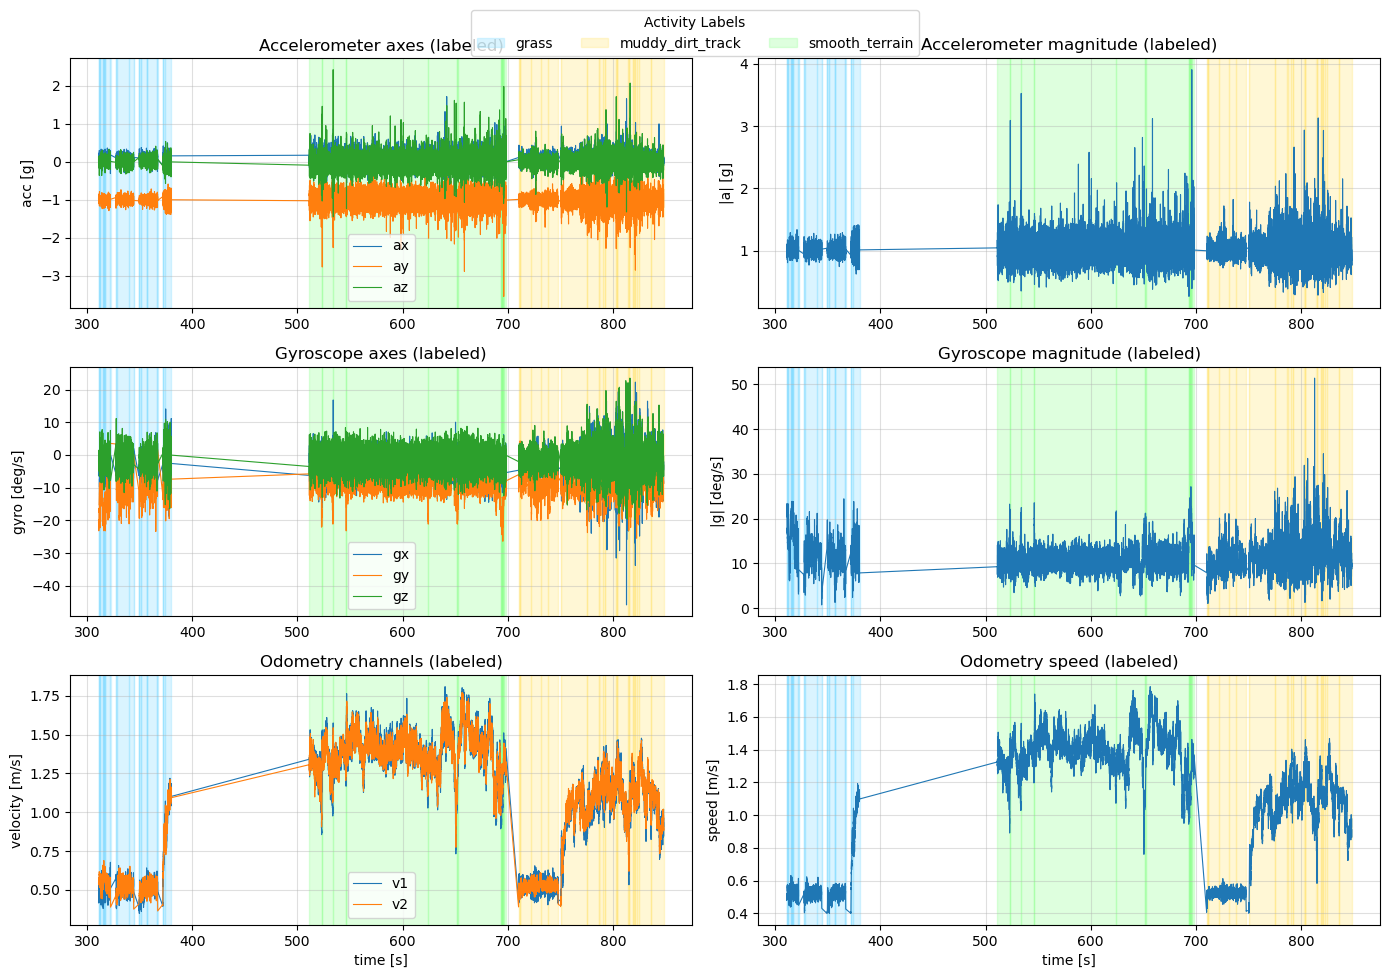

Plotting_labeled_acc for log_20260223_142511.490


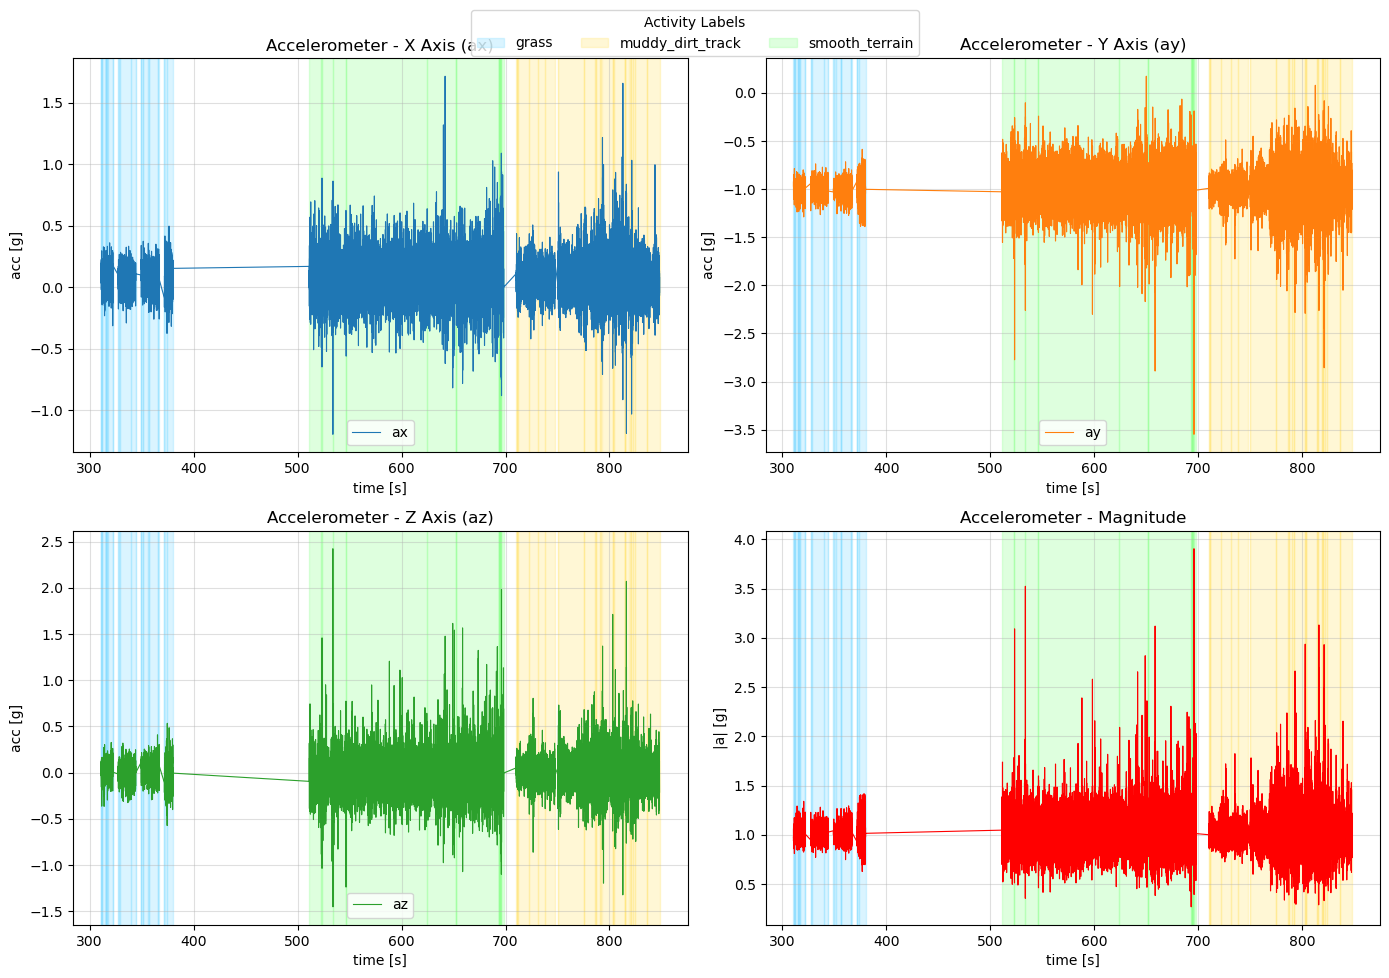

Plotting_labeled_gyro for log_20260223_142511.490


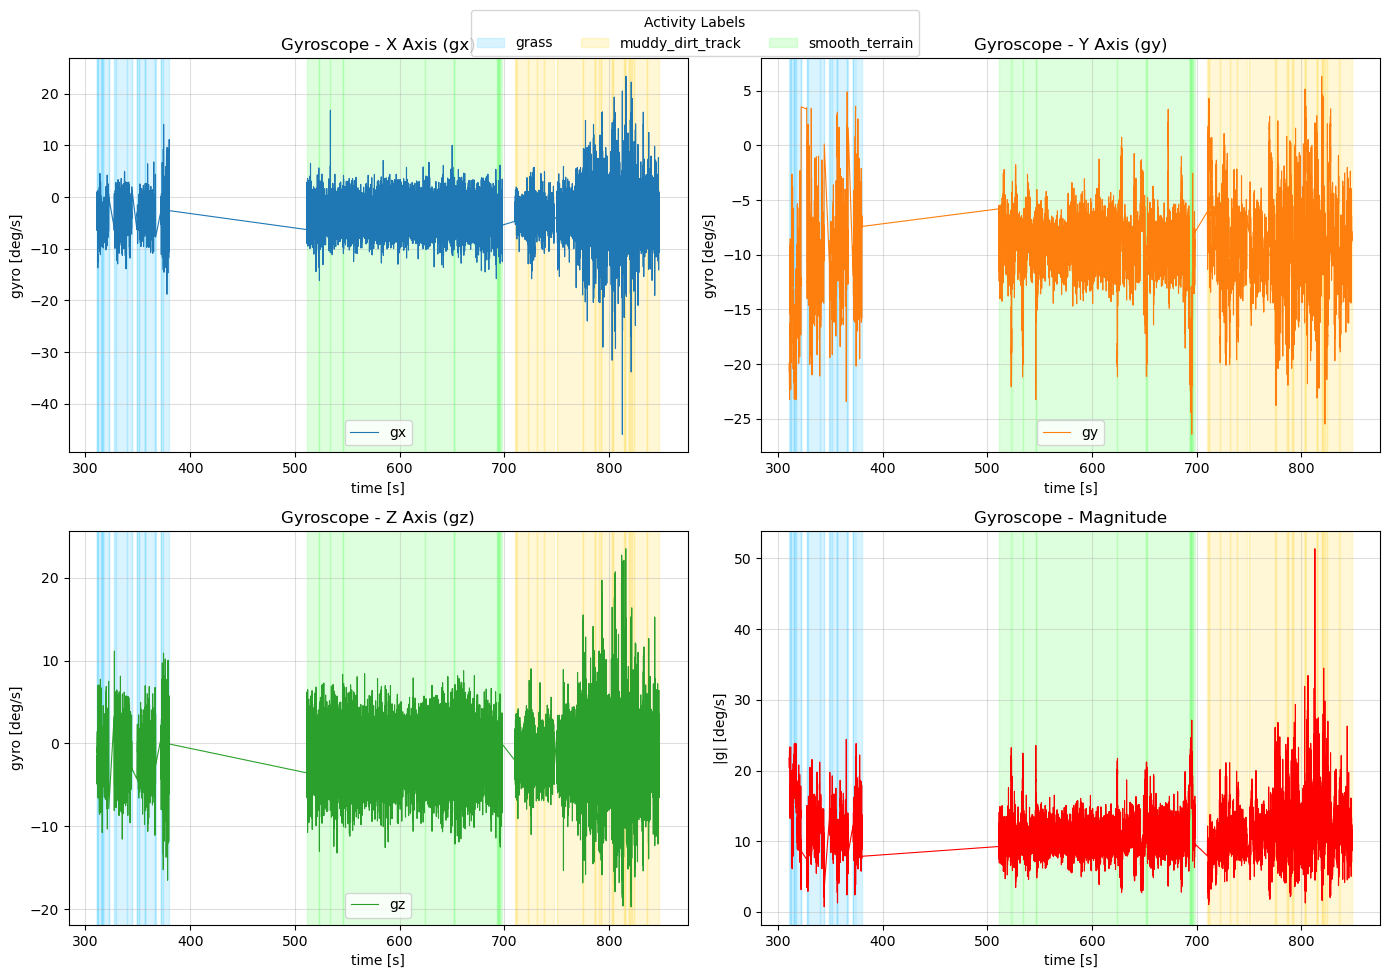

Plotting_labeled_odo for log_20260223_142511.490


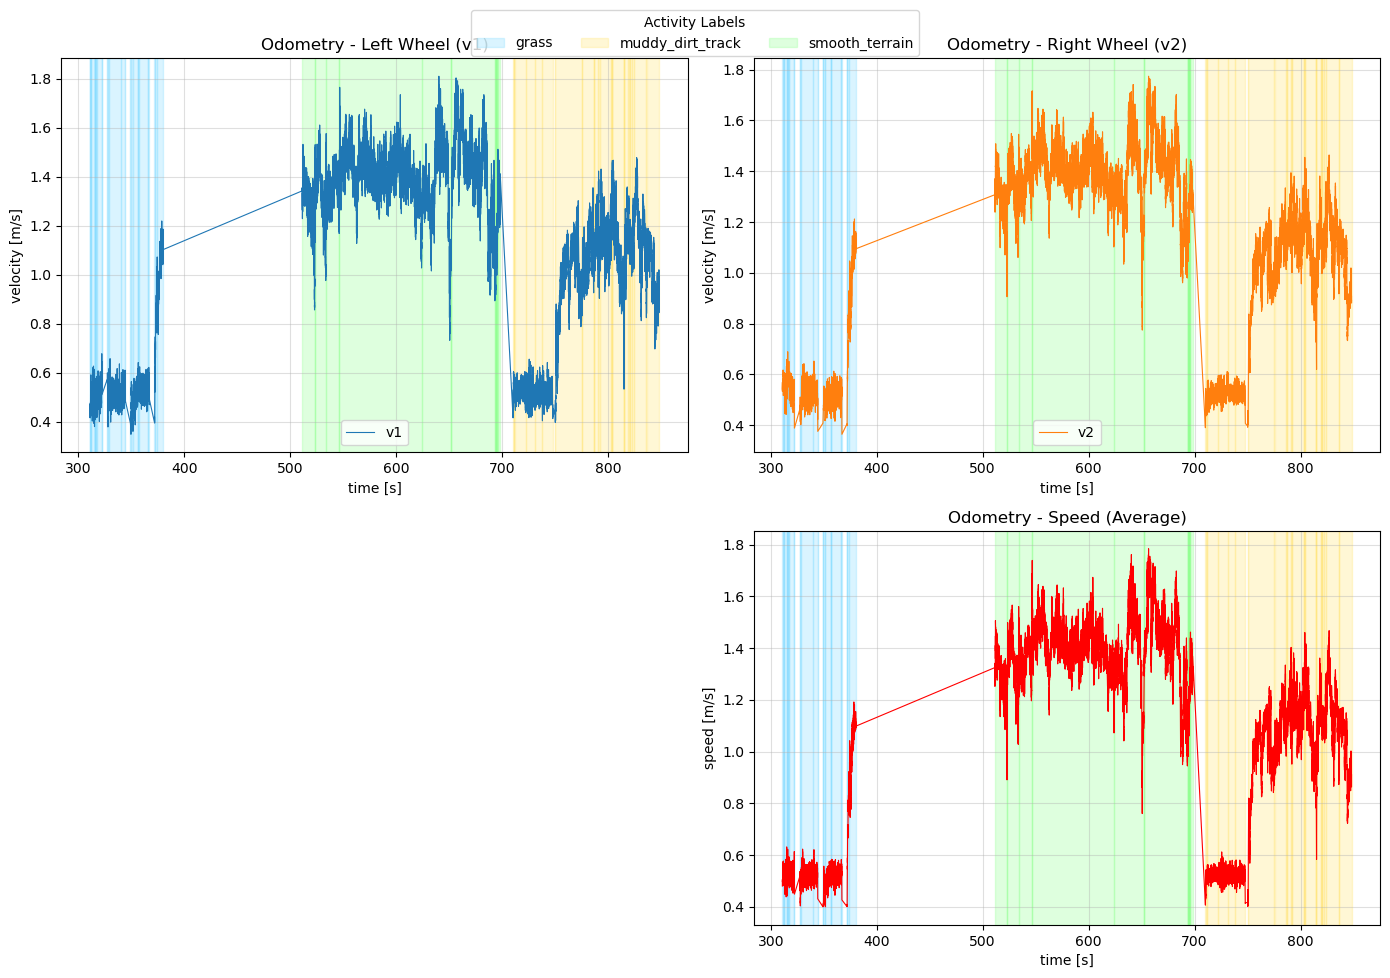


Plotting labeled sensors for log_20260226_102148.990...


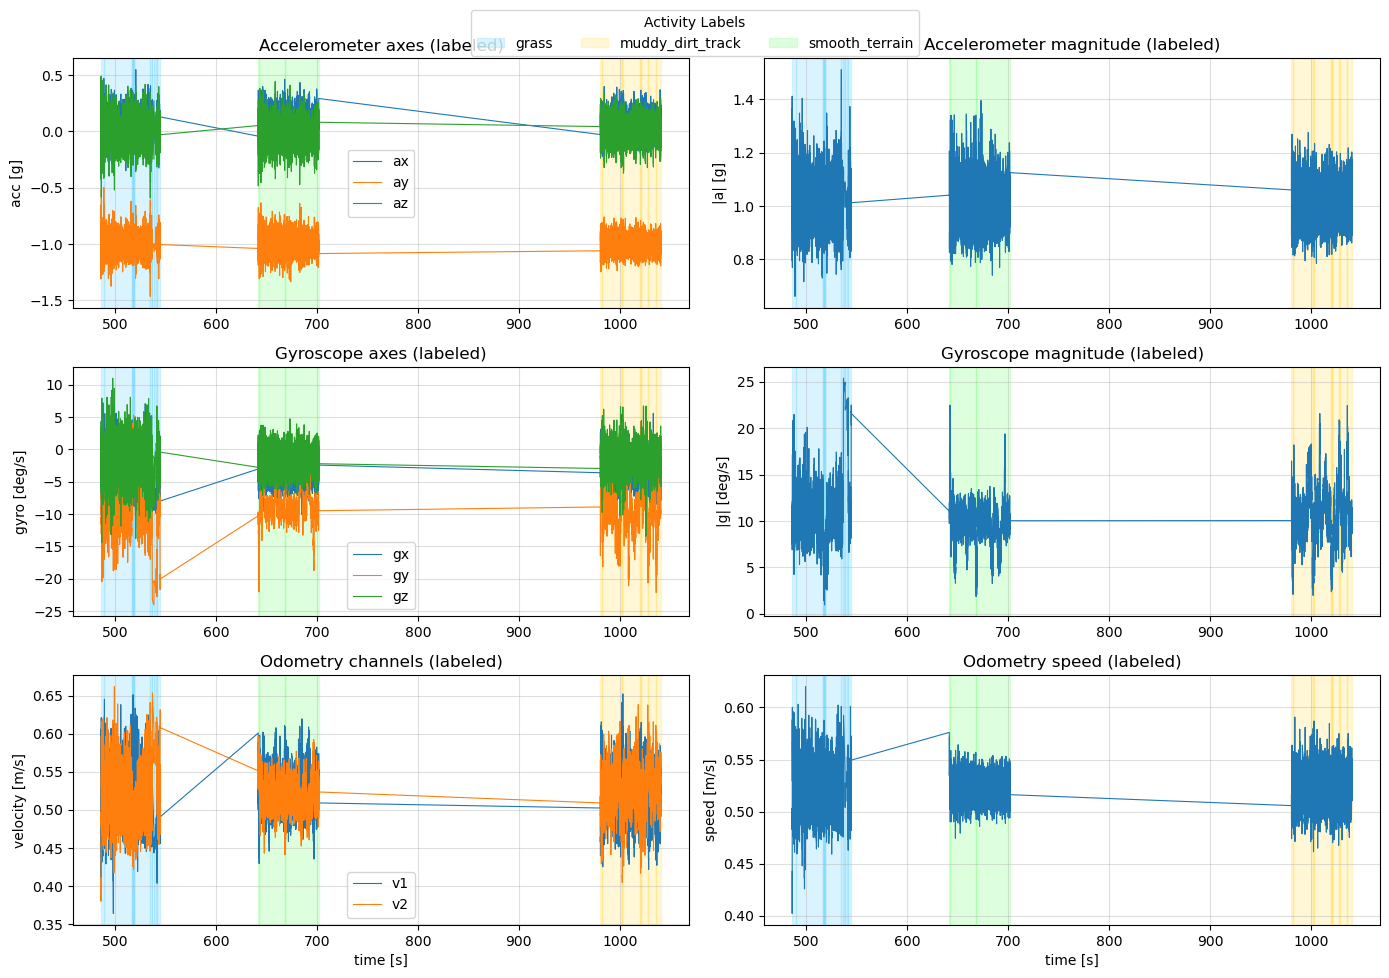

Plotting_labeled_acc for log_20260226_102148.990


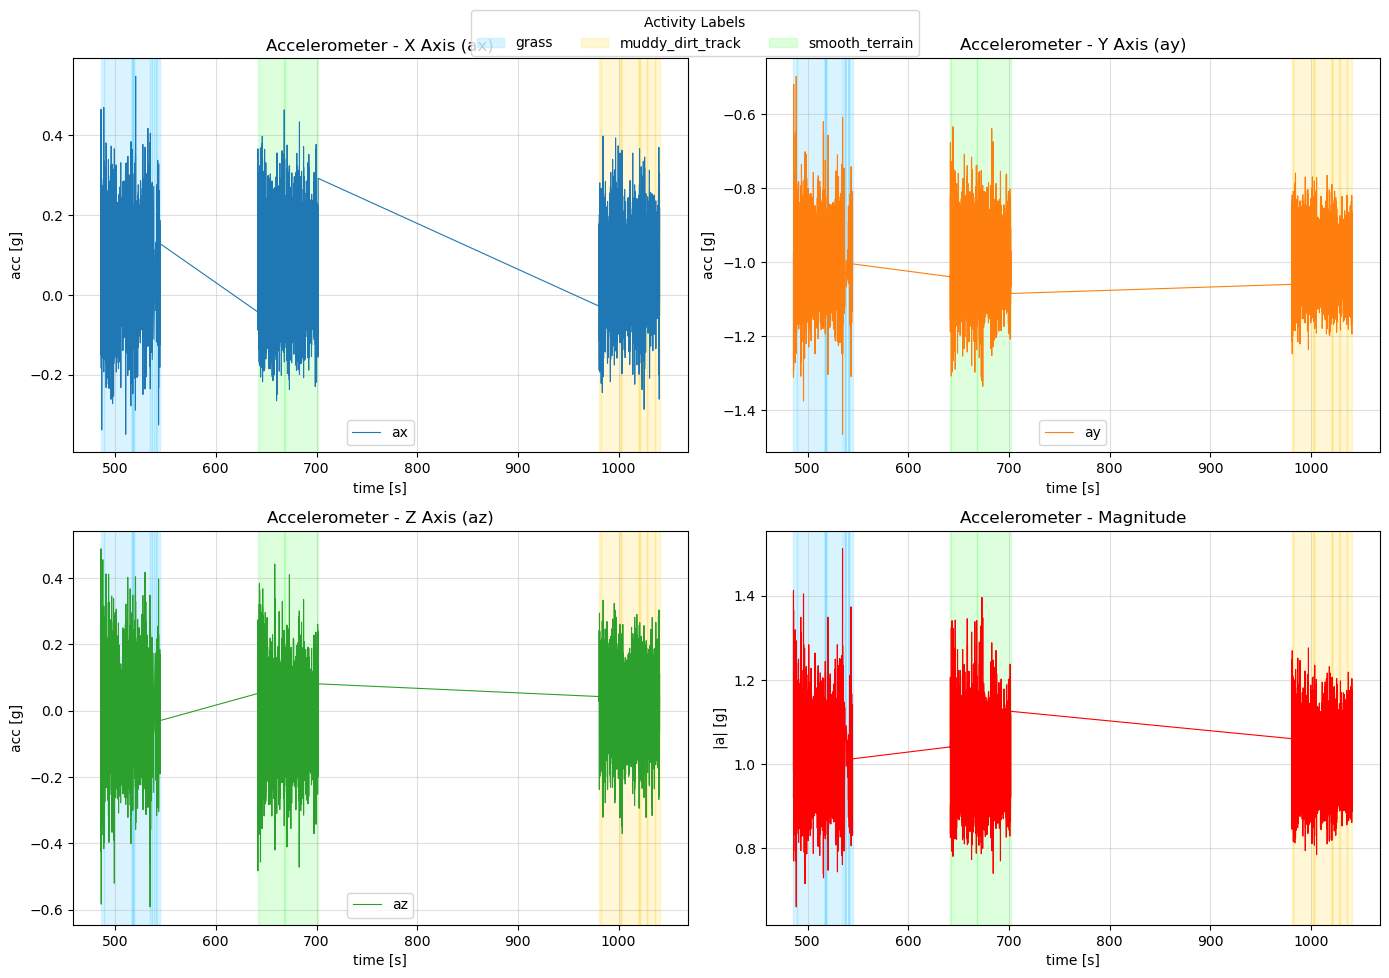

Plotting_labeled_gyro for log_20260226_102148.990


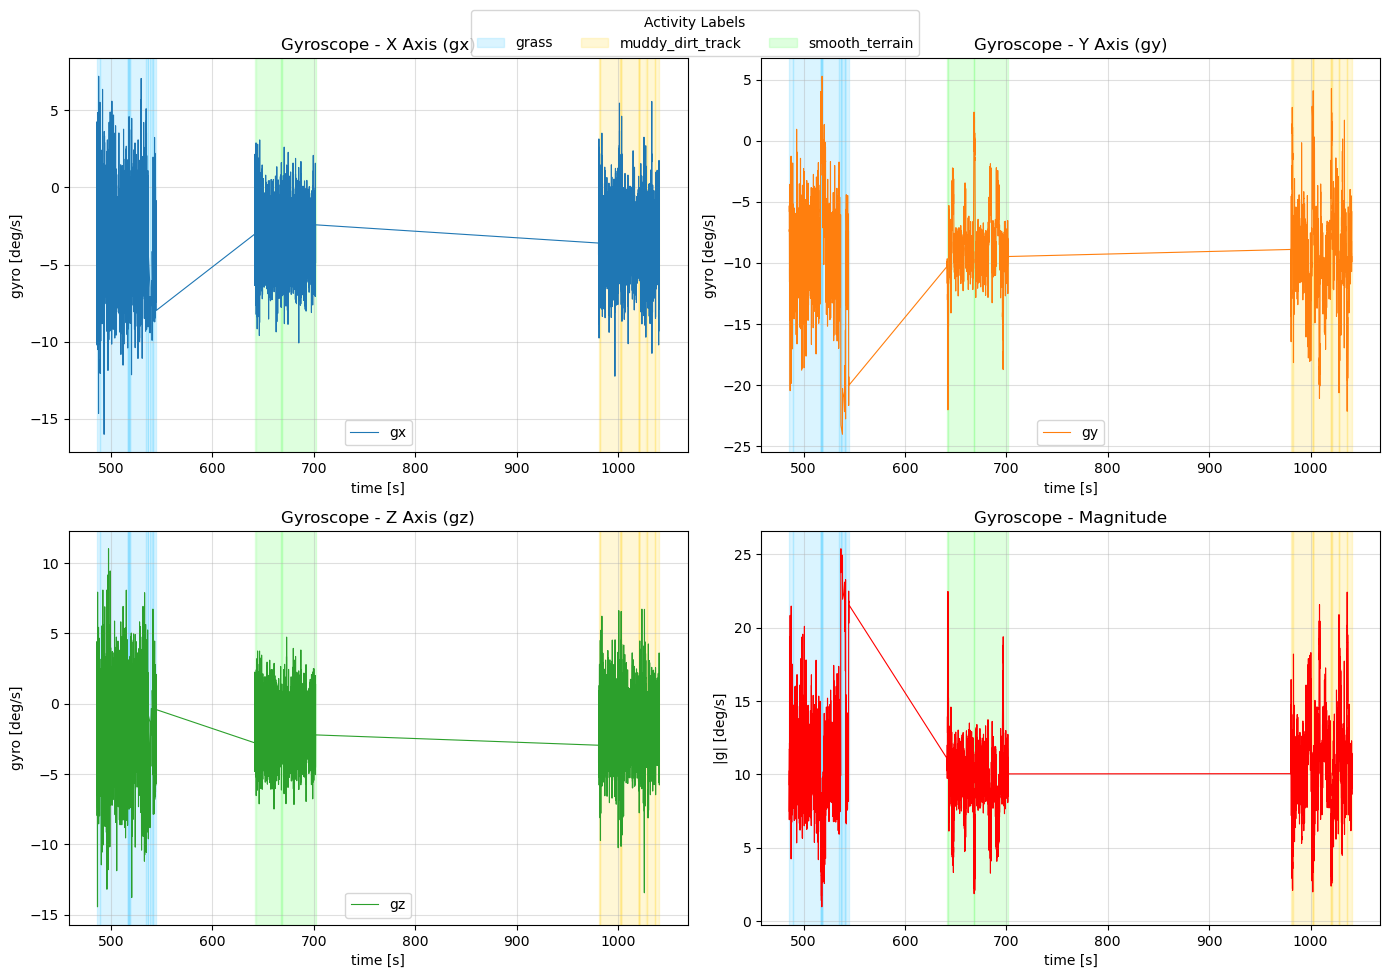

Plotting_labeled_odo for log_20260226_102148.990


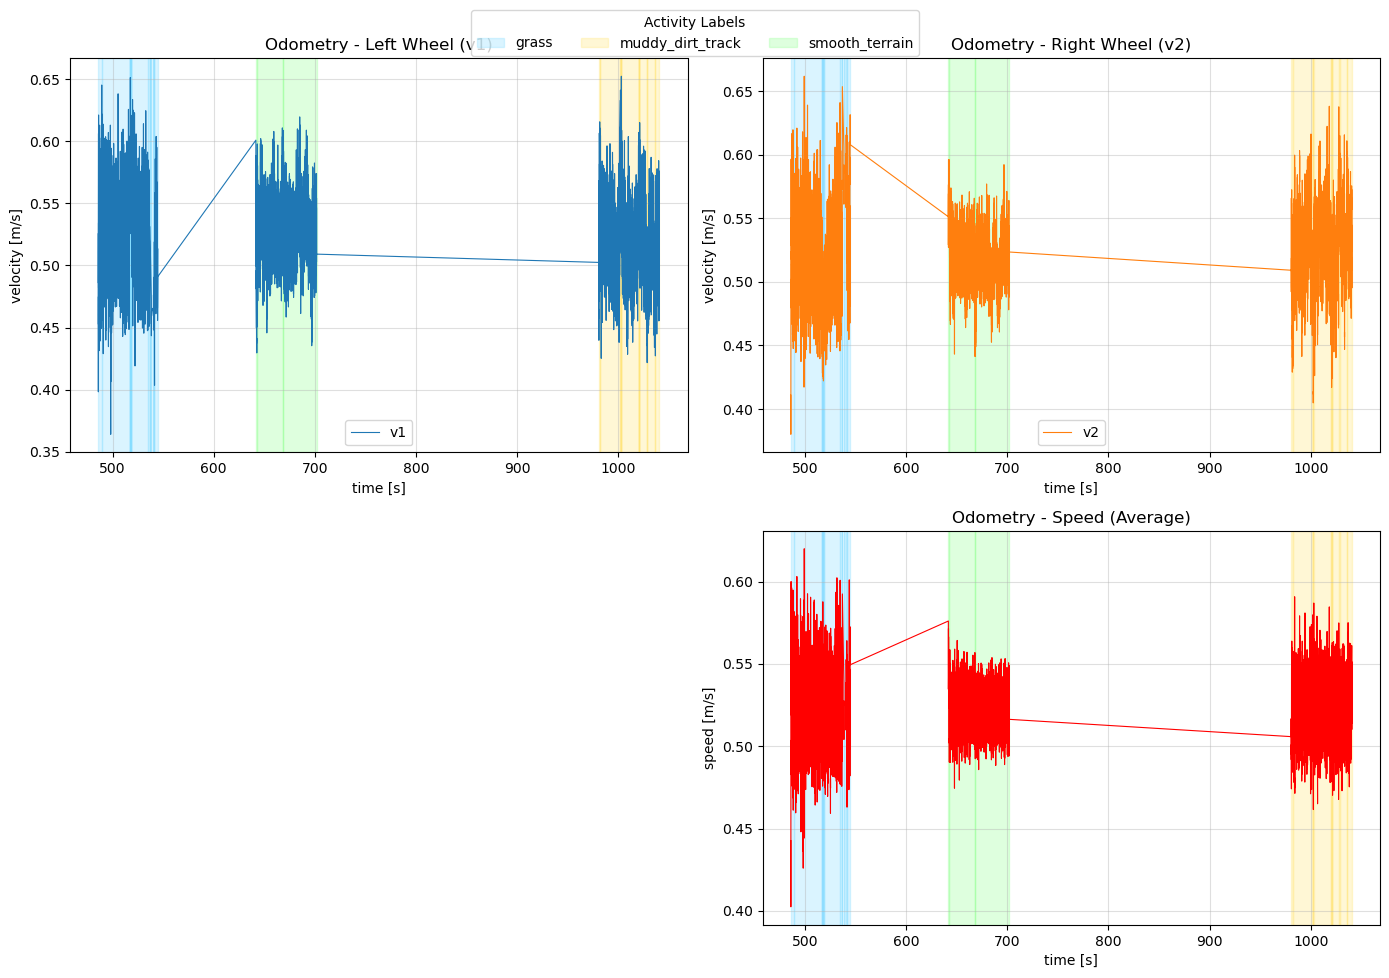


Plotting labeled sensors for log_20260309_141435.414...


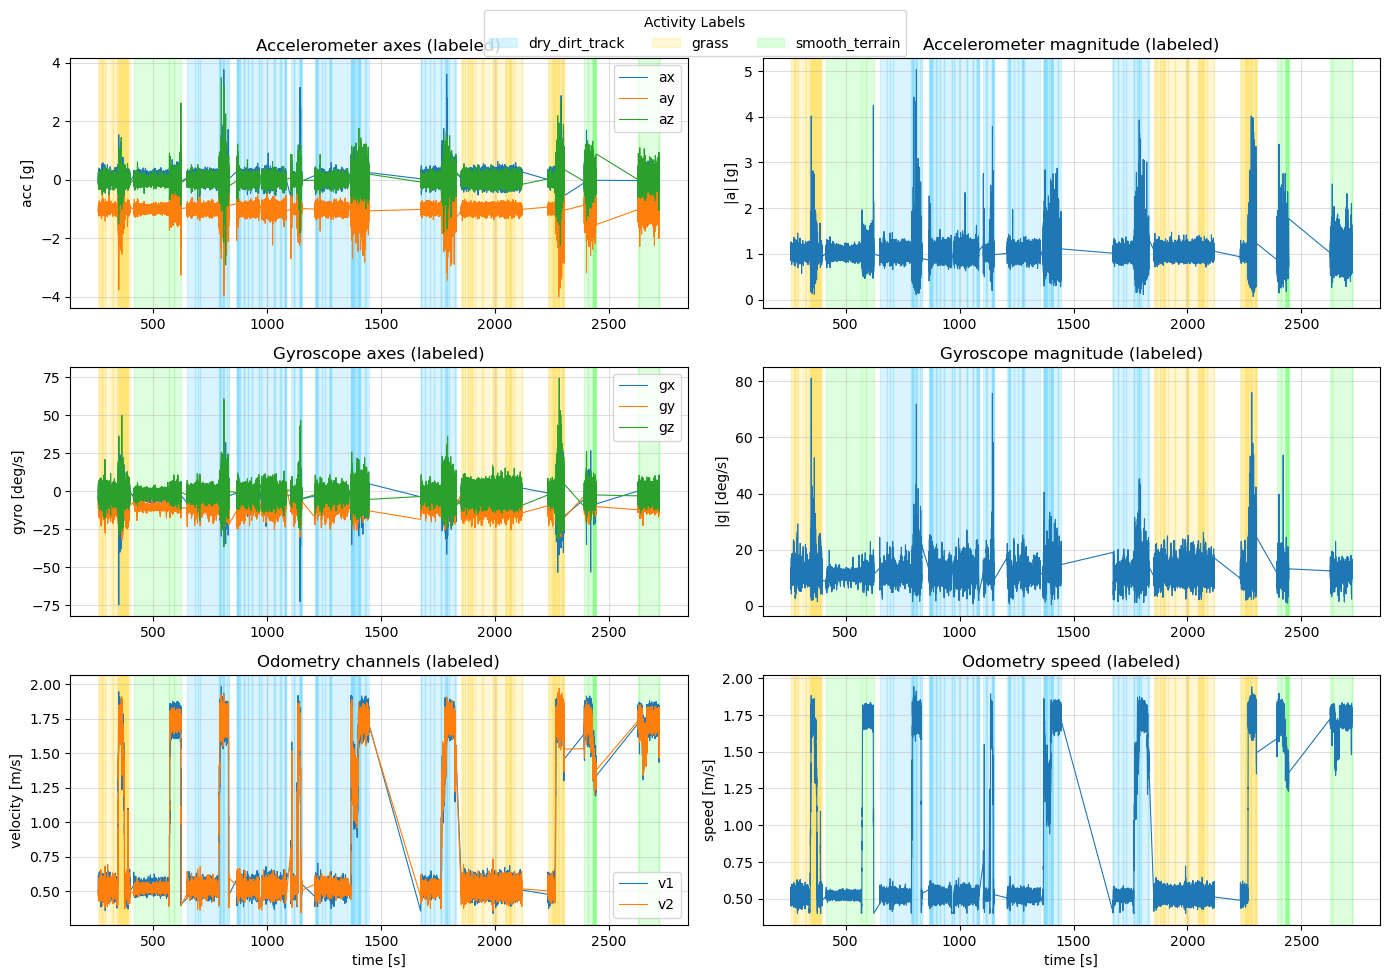

Plotting_labeled_acc for log_20260309_141435.414


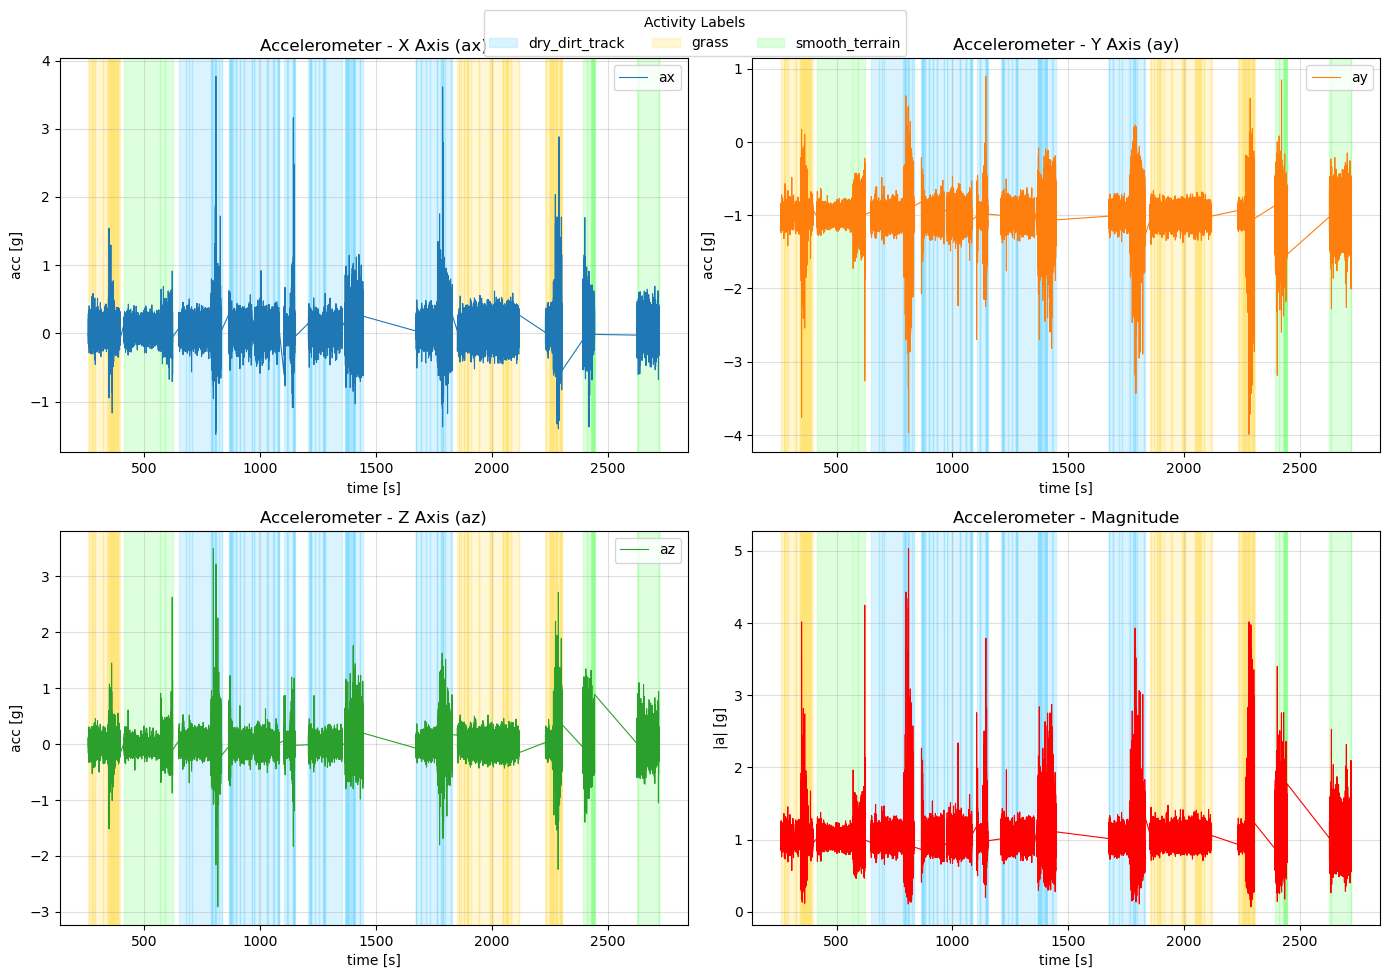

Plotting_labeled_gyro for log_20260309_141435.414


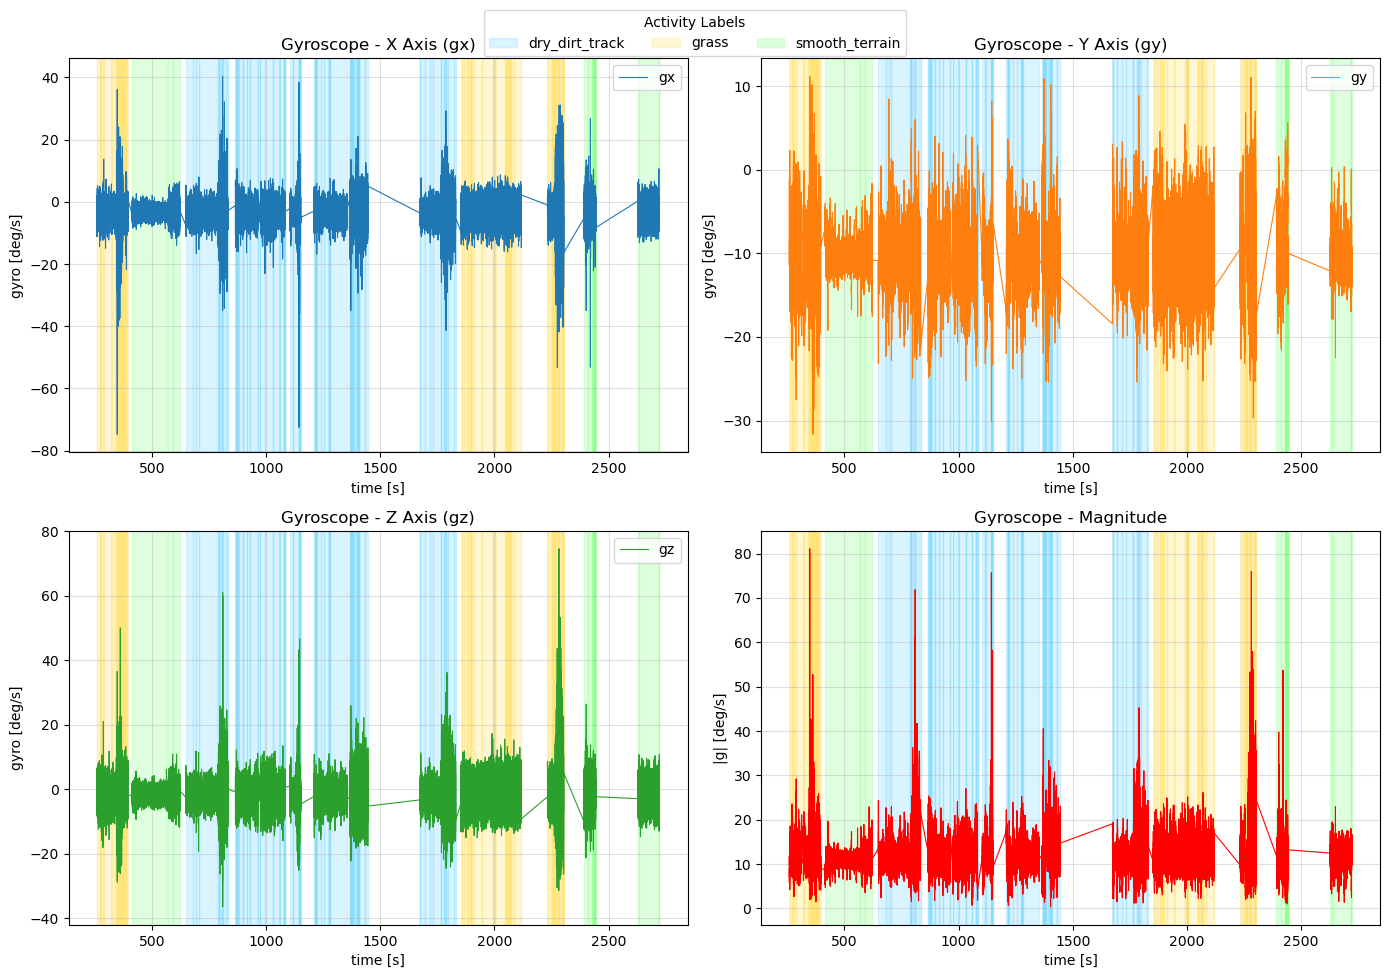

Plotting_labeled_odo for log_20260309_141435.414


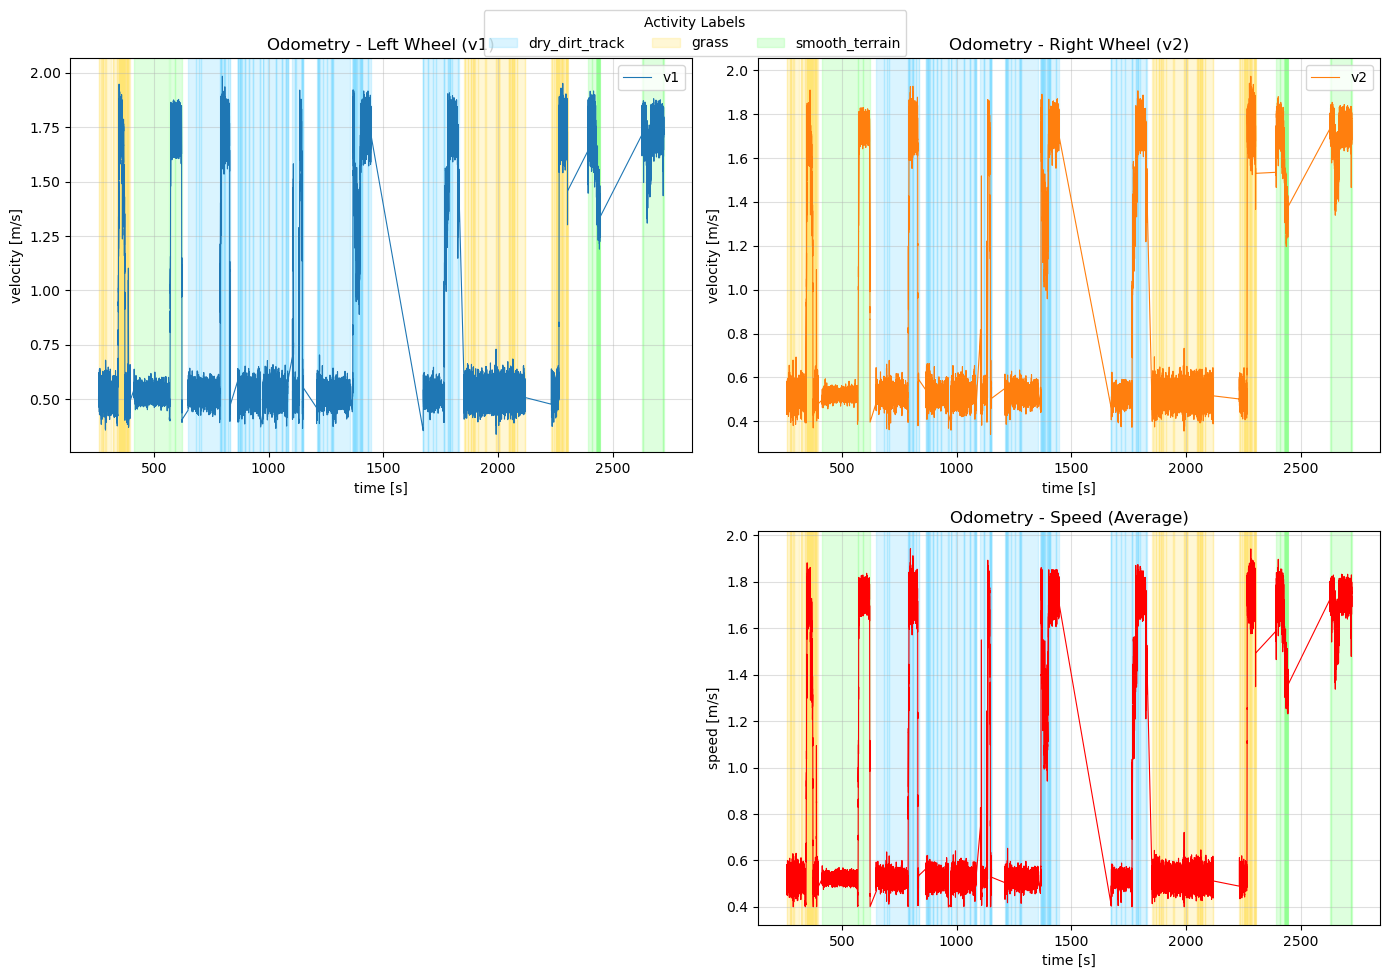

In [31]:
# Plotting after removing unlabeled samples (per run) not necessary to run every time but as a check
if labeled_df.empty:
    print("No labeled samples available to plot.")
else:
    for run_id in sorted(labeled_df['run_id'].unique()):
        run_df = labeled_df[labeled_df['run_id'] == run_id].copy()

        acc_labeled = run_df[['t', 't_rel', 'ax', 'ay', 'az', 'label']].copy()
        gyro_labeled = run_df[['t', 't_rel', 'gx', 'gy', 'gz', 'label']].copy()
        odo_labeled = run_df[['t', 't_rel', 'v1', 'v2', 'label']].copy()

        print(f"\nPlotting labeled sensors for {run_id}...")
        _ = plot_labeled_sensors(
            acc=acc_labeled,
            gyro=gyro_labeled,
            odo=odo_labeled,
            tcol='t_rel',
            show=True
        )

        print(f"Plotting_labeled_acc for {run_id}")
        plot_labeled_acc(acc_labeled, tcol='t_rel', show=True)
        print(f"Plotting_labeled_gyro for {run_id}")
        plot_labeled_gyro(gyro_labeled, tcol='t_rel', show=True)
        print(f"Plotting_labeled_odo for {run_id}")
        plot_labeled_odo(odo_labeled, tcol='t_rel', show=True)

In [32]:
# Save cleaned dataset
required_columns = [
    'run_id', 't', 't_rel',
    'ax', 'ay', 'az',
    'gx', 'gy', 'gz',
    'v1', 'v2',
    'label', 'net_speed', 'yaw_rate'
]
missing_columns = [col for col in required_columns if col not in labeled_df.columns]
if missing_columns:
    raise KeyError(f"Cannot save cleaned dataset. Missing required columns: {missing_columns}")

cleaned_dir = PROJECT_ROOT / "data" / "interim" / "cleaned"
cleaned_dir.mkdir(parents=True, exist_ok=True)
cleaned_path = cleaned_dir / "cleaned_dataset.csv"

labeled_df = labeled_df.sort_values(['run_id', 't_rel']).reset_index(drop=True)
labeled_df.to_csv(cleaned_path, index=False)

print(f"Saved cleaned dataset to: {cleaned_path}")
print(f"Shape: {labeled_df.shape}")
print(f"Columns: {list(labeled_df.columns)}")

Saved cleaned dataset to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/interim/cleaned/cleaned_dataset.csv
Shape: (211705, 14)
Columns: ['t', 't_rel', 'run_id', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'v1', 'v2', 'label', 'net_speed', 'yaw_rate']
